# Linear Regression From Scratch

## Objective

In the previous notebook, we used Scikit-learn's `LinearRegression` to create a baseline model for predicting housing prices.

The library gave us the learned coefficients and predictions, but it hid the process used to obtain those parameters.

In this notebook, we will rebuild the core idea of linear regression ourselves.

Our goal is not to create a production-ready implementation. The goal is to understand the mathematics and the relationship between:

- Linear regression
- Predictions
- Error
- Mean Squared Error (MSE)
- Gradients
- Gradient Descent
- Model parameters

We will first work with a very small one-feature dataset so that the process is easy to visualize. Once the algorithm is understood, we will extend the same idea to our housing dataset with eight features.

## 1. Create a Simple Dataset

Before applying linear regression to the housing dataset, we will start with a very small artificial dataset.

The dataset contains five observations:

| x | y |
|---|---|
| 1 | 2 |
| 2 | 4 |
| 3 | 6 |
| 4 | 8 |
| 5 | 10 |

If we look at the data, we can see that the relationship appears to be:

$$
y = 2x
$$

However, our algorithm will not be given this relationship.

We will start with unknown parameters and use gradient descent to learn them.

Starting with a simple dataset makes it possible to observe exactly what happens during the learning process before applying the same ideas to the much larger housing dataset.

In [358]:
import numpy as np

x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

## 2. Define the Linear Regression Model

For a single feature, our linear regression model has the form:

$$
y = wx + b
$$

where:

- $x$ is the input feature
- $w$ is the weight (slope)
- $b$ is the bias (intercept)
- $y$ is the predicted value

Our goal is to find values of $w$ and $b$ that produce predictions as close as possible to the actual values of $y$.

For our simple dataset, the relationship appears to be:

$$
y = 2x
$$

Therefore, the ideal parameters would be approximately:

$$
w=2,  b=0
$$

However, we will **not give these values to the algorithm**. We will start with arbitrary values and allow gradient descent to learn them.

In [359]:
w = 0
b = 0

## 3. Make the Initial Predictions

We currently know nothing about the correct slope or intercept.

We therefore start with:

$$
w=0
$$

and

$$
b=0
$$

Our model is therefore:

$$
y=0x+0
$$

This means that regardless of the input value, the model will initially predict zero.

This is intentionally a poor starting point. We want to see whether gradient descent can gradually improve these parameters.

In [360]:
y_pred = w * x + b
print(y_pred)

[0 0 0 0 0]


## 4. Measuring Prediction Error With MSE

The model has made predictions, but we need a numerical way to measure how far those predictions are from the actual values.

We will use Mean Squared Error (MSE).

For each observation, we calculate the error:

$$
e_i = y_i - \hat{y}_i
$$

We square the error so that positive and negative errors cannot cancel each other:

$$
e_i^2 = (y_i - \hat{y}_i)^2
$$

Finally, we take the average:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

A smaller MSE means that the predictions are, overall, closer to the actual values.

Our goal will therefore be:

$$
\boxed{\text{Minimize MSE}}
$$

In [361]:
mse = np.mean((y - y_pred) ** 2)

print(mse)

44.0


## 7. Perform One Gradient Descent Update

The gradient tells us which direction increases the MSE.

To minimize the MSE, we move in the opposite direction of the gradient.

The update rule is:

$$
w_{new} = w - \alpha \frac{\partial MSE}{\partial w}
$$

$$
b_{new} = b - \alpha \frac{\partial MSE}{\partial b}
$$

where $\alpha$ is the learning rate.

For our first update, we will use:

$$
\alpha = 0.01
$$

The learning rate controls how large each step is.

A very large learning rate can cause us to overshoot the minimum, while a very small learning rate can make learning unnecessarily slow.

In [362]:
learning_rate = 0.01

dw = (-2 / len(x)) * np.sum(x * (y - y_pred))
db = (-2 / len(x)) * np.sum(y - y_pred)

w = w - learning_rate * dw
b = b - learning_rate * db

print("dw =", dw)
print("db =", db)
print("w =", w)
print("b =", b)


dw = -44.0
db = -12.0
w = 0.44
b = 0.12


## 8. The First Gradient Descent Update

We have calculated the gradients of MSE with respect to the two model parameters:

$$
\frac{\partial MSE}{\partial w} = -44
$$

$$
\frac{\partial MSE}{\partial b} = -12
$$

The negative gradients tell us that increasing both $w$ and $b$ will move us toward a lower MSE.

We use a learning rate of:

$$
\alpha = 0.01
$$

Gradient descent updates each parameter by moving in the opposite direction of its gradient:

$$
w_{new} = w - \alpha\frac{\partial MSE}{\partial w}
$$

$$
b_{new} = b - \alpha\frac{\partial MSE}{\partial b}
$$

Starting from $w=0$ and $b=0$:

$$
w_{new}=0-(0.01)(-44)=0.44
$$

$$
b_{new}=0-(0.01)(-12)=0.12
$$

Therefore, after one update:

$$
w=0.44,\qquad b=0.12
$$

The model has now taken its first step toward the values that minimize the error.

## 9. Evaluate the New Model

After updating $w$ and $b$, we need to check whether the new model is actually better.

The new model is:

$$
\hat{y}=0.44x+0.12
$$

We will use the updated parameters to make predictions again and then calculate the new MSE.

If gradient descent moved in the correct direction, the MSE should be lower than our original value of 44.

This gives us a simple way to verify that the update worked.

In [363]:
y_pred = w * x + b

print("Predictions:", y_pred)

mse = np.mean((y - y_pred) ** 2)

print("MSE:", mse)

Predictions: [0.56 1.   1.44 1.88 2.32]
MSE: 25.660800000000002


## 10. The Second Learning Step

After the first update, our model became:

$$
\hat{y}=0.44x+0.12
$$

Its MSE decreased from 44 to approximately 25.66.

We can now repeat the same process.

1. Make predictions using the current parameters.
2. Calculate the prediction errors.
3. Calculate the gradients.
4. Update $w$ and $b$.
5. Calculate the new MSE.

The important observation is that gradient descent does not know the final answer in advance. It repeatedly uses the current error to decide how the parameters should change.

In [364]:
dw = (-2 / len(x)) * np.sum(x * (y - y_pred))
db = (-2 / len(x)) * np.sum(y - y_pred)

print("dw =", dw)
print("db =", db)

dw = -33.6
db = -9.120000000000001


## 11. Observing the Gradient

After the first update, the gradient was:

$$
dw=-44
$$

After recalculating it at the new position, we obtained:

$$
dw=-33.6
$$

Although $-33.6$ is numerically greater than $-44$, its magnitude is smaller:

$$
|-33.6| < |-44|
$$

This indicates that the gradient is moving toward zero.

The gradient is still negative, so increasing $w$ should still reduce the MSE. However, the size of the gradient has decreased, meaning that we are getting closer to the minimum.

The same behavior occurs for $b$:

$$
db=-12 \rightarrow -9.12
$$

Gradient descent will continue taking smaller effective steps as the gradients approach zero.

In [365]:
w = w - learning_rate * dw
b = b - learning_rate * db

print("w =", w)
print("b =", b)

w = 0.776
b = 0.2112


## 12. Visualizing the Current Model

Our current parameters after two gradient descent updates are:

$$
w = 0.776
$$

$$
b = 0.2112
$$

Therefore, our current model is:

$$
\hat{y} = 0.776x + 0.2112
$$

We can plot the original data points and the line produced by our current model.

The data points represent the actual values, while the line represents the predictions made by our model.

As gradient descent continues, we expect the line to move toward a position that passes as closely as possible through the data points.|

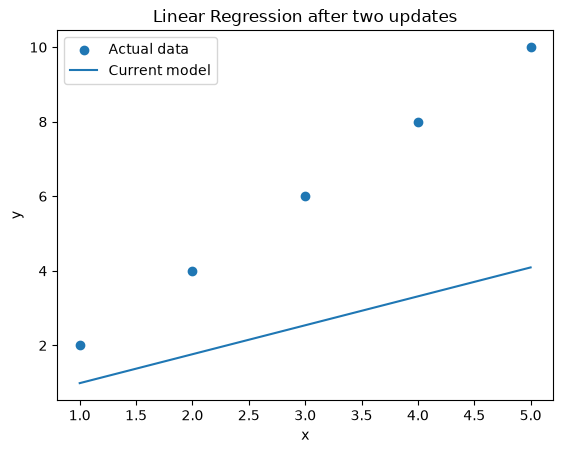

In [366]:
import matplotlib.pyplot as plt

y_pred = w * x + b

plt.scatter(x, y, label = "Actual data")
plt.plot(x, y_pred, label = "Current model")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression after two updates")
plt.legend()
plt.show()

## 13. Repeating Gradient Descent

A single gradient descent update only makes a small improvement.

The complete learning process consists of repeatedly performing the same steps:

1. Make predictions using the current $w$ and $b$.
2. Calculate the gradients.
3. Update $w$ and $b$.
4. Repeat.

Each iteration gives the model another opportunity to reduce the MSE.

We call each complete pass through these steps an **iteration**.

Instead of manually performing hundreds of updates, we can use a loop to automate the process.

In [367]:
w = 0
b = 0

learning_rate = 0.01

In [368]:
mse_history = []

for i in range(1000):

    # 1. Make predictions
    y_pred = w * x + b

    # 2. Calculate gradients
    dw = (-2 / len(x)) * np.sum(x * (y - y_pred))
    db = (-2 / len(x)) * np.sum(y - y_pred)

    # 3. Update parameters
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # 4. Calculate and store MSE
    mse = np.mean((y - y_pred) ** 2)
    mse_history.append(mse)

In [369]:
print("Final w =", w)
print("Final b =", b)
print("Final MSE =", mse_history[-1])

Final w = 1.9951803506719779
Final b = 0.017400463340610635
Final MSE = 5.548510370387798e-05


## 14. Visualizing Convergence

Gradient descent repeatedly updates the model parameters in an attempt to reduce the MSE.

We stored the MSE after each iteration in `mse_history`.

By plotting MSE against the number of iterations, we can visualize the learning process.

If gradient descent is working correctly, the curve should generally decrease and eventually flatten near its minimum.

This point where further iterations produce very little improvement is called **convergence**.

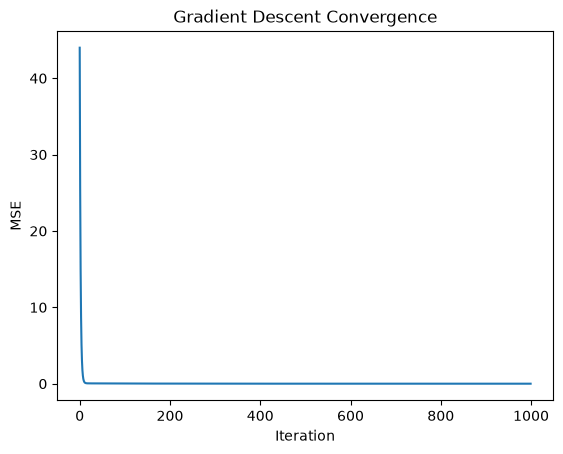

In [370]:
plt.plot(mse_history)

plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Gradient Descent Convergence")

plt.show()

## 15. Visualizing the Line During Training

Gradient descent changes the model parameters after every iteration.

Because our model is:

$$
\hat{y} = wx + b
$$

changing $w$ changes the slope of the line, while changing $b$ changes its vertical position.

Instead of looking only at the final model, we will save the parameters at several stages of training and plot the corresponding lines.

This allows us to directly visualize the process we have been describing:

$$
\text{Initial line}
\rightarrow
\text{update parameters}
\rightarrow
\text{new line}
\rightarrow
\text{update again}
\rightarrow
\text{better line}
$$

Eventually, the line should approach the relationship represented by our data.

In [371]:
w = 0
b = 0

learning_rate = 0.01

checkpoints = [0, 1, 2, 10, 50, 100]
saved_parameters = {}

for i in range(101):

    # Save parameters before updating
    if i in checkpoints:
        saved_parameters[i] = (w, b)

    # Make predictions
    y_pred = w * x + b

    # Calculate gradients
    dw = (-2 / len(x)) * np.sum(x * (y - y_pred))
    db = (-2 / len(x)) * np.sum(y - y_pred)

    # Update parameters
    w = w - learning_rate * dw
    b = b - learning_rate * db


In [372]:
for iteration, (w, b) in saved_parameters.items():
    print (
        f"Iteration {iteration}: "
        f"w = {w:.4f}, "
        f"b = {b:.4f}"
    )

Iteration 0: w = 0.0000, b = 0.0000
Iteration 1: w = 0.4400, b = 0.1200
Iteration 2: w = 0.7760, b = 0.2112
Iteration 10: w = 1.7374, b = 0.4628
Iteration 50: w = 1.8797, b = 0.4344
Iteration 100: w = 1.8984, b = 0.3667


## Comparing the Model at Different Iterations

Each saved pair of parameters $(w,b)$ represents a different version of our model.

We will plot these lines together with the actual data points.

The early lines should be far from the data because the model has not learned much yet.

As the number of iterations increases, the lines should move toward the relationship represented by the observations.

This gives us a visual interpretation of gradient descent: **the algorithm is repeatedly changing the parameters to reduce the prediction error.**

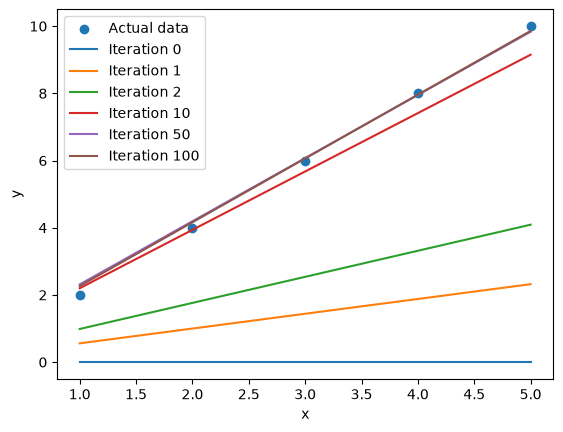

In [373]:
plt.scatter(x, y, label = "Actual data")

for iteration, (w, b) in saved_parameters.items():
    y_line = w * x + b
    plt.plot(x, y_line, label = f"Iteration {iteration}")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## 16. From One Feature to Multiple Features

Our earlier model used one input feature:

$$
\hat{y}=wx+b
$$

The housing dataset contains eight features for each observation.

We can represent them as:

$$
x_1,x_2,\ldots,x_8
$$

Each feature gets its own weight:

$$
w_1,w_2,\ldots,w_8
$$

Therefore, our model becomes:

$$
\hat{y}
=
w_1x_1+
w_2x_2+
\cdots+
w_8x_8+b
$$

The important idea is that nothing fundamental has changed.

With one feature, the model learns one weight and one bias.

With eight features, it learns eight weights and one bias.

The prediction is still calculated by multiplying each input by its corresponding weight, adding the results, and finally adding the bias.

## 17. A Two-Feature Linear Regression Model

We previously worked with a single feature:

$$
\hat{y}=wx+b
$$

Now suppose every observation has two features:

$$
x_1,\ x_2
$$

Each feature gets its own weight:

$$
w_1,\ w_2
$$

Our model becomes:

$$
\hat{y}=w_1x_1+w_2x_2+b
$$

The idea is exactly the same as before. The only difference is that the prediction now combines information from two input features.

We will use a very small dataset so that we can see how the individual values are combined.

In [374]:
X = np.array([
    [1, 2],
    [2, 1],
    [3, 2],
    [4, 1]
])

y = np.array([5, 6, 9, 10])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4, 2)
y shape: (4,)


## 18. Representing Multiple Weights

With two features, we have two weights:

$$
w_1,\ w_2
$$

We can store them together as a vector:

$$
\mathbf{w}=
\begin{bmatrix}
w_1\\
w_2
\end{bmatrix}
$$

This becomes especially useful when the number of features grows.

Instead of creating separate variables such as `w1`, `w2`, ..., `w8`, we can store all weights inside one NumPy array.

In [375]:
w = np.array([0.0, 0.0])
b = 0.0

print("w:", w)
print("b:", b)

w: [0. 0.]
b: 0.0


In [376]:
x_first = X[0]

prediction = w[0] * x_first[0] + w[1] * x_first[1] + b

print(prediction)

0.0


## 19. Using the Dot Product

The expression:

$$
\mathbf{w}^T\mathbf{x}
$$

is the dot product between the weight vector and the feature vector.

For two features:

$$
\mathbf{w}^T\mathbf{x}
=
w_1x_1+w_2x_2
$$

Therefore:

$$
\hat{y}=\mathbf{w}^T\mathbf{x}+b
$$

is simply a compact mathematical representation of:

$$
\hat{y}=w_1x_1+w_2x_2+b
$$

The dot product becomes extremely useful when we have many features because it allows us to perform the same calculation without manually writing every multiplication.

In [377]:
prediction = np.dot(w, X[0]) + b
print(prediction)

0.0


In [378]:
y_pred = X @ w + b
print(y_pred)

[0. 0. 0. 0.]


## 20. Gradients With Multiple Features

With one feature, we calculated one gradient for the weight:

$$
\frac{\partial MSE}{\partial w}
=
-\frac{2}{n}\sum_{i=1}^{n}x_i(y_i-\hat{y}_i)
$$

With multiple features, every feature has its own weight, so every weight needs its own gradient.

For feature $j$:

$$
\frac{\partial MSE}{\partial w_j}
=
-\frac{2}{n}
\sum_{i=1}^{n}
x_{ij}(y_i-\hat{y}_i)
$$

Therefore, for two features we have:

$$
dw_1
=
-\frac{2}{n}
\sum x_1(y-\hat{y})
$$

and:

$$
dw_2
=
-\frac{2}{n}
\sum x_2(y-\hat{y})
$$

The idea has not changed. We calculate how the prediction error is related to each feature and use that information to decide how each weight should change.

In [379]:
dw1 = (-2 / len(X)) * np.sum(X[:, 0]*(y - y_pred))
dw2 = (-2 / len(X)) * np.sum(X[:, 1]*(y - y_pred))

print(dw1)
print(dw2)

-42.0
-22.0


## 21. Vectorizing the Gradient Calculation

Calculating every gradient separately would become cumbersome as the number of features increases.

Linear algebra gives us a compact way to calculate all weight gradients simultaneously:

$$
dw=-\frac{2}{n}X^T(y-\hat{y})
$$

Here:

- $X$ contains all observations and features
- $X^T$ is the transpose of $X$
- $y-\hat{y}$ contains the prediction errors
- `dw` contains the gradient for every weight

The result has one gradient for each feature.

This is the same calculation we performed manually, but expressed in a form that works for any number of features.

In [380]:
y_pred = X @ w + b

dw = (-2 / len(X)) * X.T @ (y - y_pred)

print(dw)

[-42. -22.]


In [381]:
def gradient_descent(X, y, learning_rate = 0.01, iterations = 1000):

    #Initialize weights and bias
    w = np.zeros(X.shape[1])
    b = 0.0

    mse_history = []

    for i in range(iterations):

        #Calculate predictions
        y_pred = X @ w + b

        #Calculate error
        error = y - y_pred

        #Calculate gradients
        dw = (-2 / len(X)) * X.T @ error
        db = (-2 / len(X)) * np.sum(error)

        #Update weights and bias
        w = w - learning_rate * dw
        b = b - learning_rate * db

        #Calculate and store MSE
        mse = np.mean(error ** 2)
        mse_history.append(mse)

    return w, b, mse_history, y_pred

In [382]:
w, b, mse_history, y_pred = gradient_descent(X, y)

print("Weights:", w)
print("Bias:", b)
print("Final MSE", mse)
print("Predictions:", y_pred)

Weights: [2.020019   1.05343574]
Bias: 0.865394945269226
Final MSE 5.548510370387798e-05
Predictions: [4.99228037 5.95884176 9.0323446  9.99890598]


## Observing Convergence

We stored the MSE after every iteration in `mse_history`.

If gradient descent is working correctly, the MSE should generally decrease as the model learns better parameters.

A decreasing MSE means that our predictions are getting closer to the actual values.

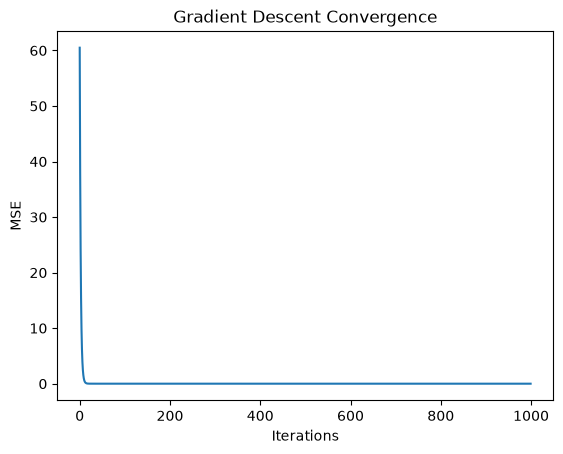

In [383]:
plt.plot(mse_history)
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.title("Gradient Descent Convergence")

plt.show()

## Visualizing the Learned Model

With two input features, linear regression no longer produces a line in 2D.

The model is:

$$
\hat{y} = w_1x_1 + w_2x_2 + b
$$

This represents a plane in three-dimensional space.

We can visualize the actual observations as points and the predictions made by our model as a fitted plane.

If the model fits the data well, the actual points should lie close to the plane.

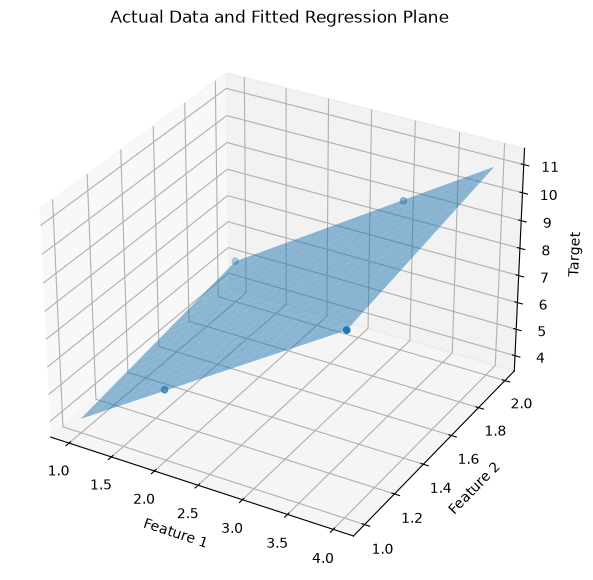

In [384]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Actual data points
ax.scatter(X[:, 0], X[:, 1], y)

# Create a grid for the plane
x1_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 20)
x2_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 20)

x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Calculate predicted y values for every point on the grid
y_grid = w[0] * x1_grid + w[1] * x2_grid + b

# Plot the fitted plane
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.5)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Target")
ax.set_title("Actual Data and Fitted Regression Plane")

plt.show()

### Interpretation

The points represent the actual target values, while the plane represents the values predicted by our linear regression model.

Gradient descent learned the weights and bias that determine the position and orientation of this plane.

Unlike the one-feature case, where the model produces a line, a two-feature linear regression model produces a plane.

The goal of gradient descent is to find the parameters that make this plane fit the observed data as closely as possible by minimizing the Mean Squared Error.

## Prediction Function

Training and prediction are two separate steps.

During training, gradient descent learns the weights and bias.

Once the parameters have been learned, we can use them to make predictions on new data.

For multiple linear regression, the prediction formula is:

$$
\hat{y} = X\mathbf{w} + b
$$

The prediction function does not learn anything. It simply takes the learned weights and bias and calculates the predicted target values.

In [385]:
def predict(X, w, b):
    return X @ w + b

In [386]:
predictions = predict(X, w, b)

print("Predictions:", predictions)
print("Actual values:", y)

Predictions: [4.99228543 5.95886869 9.03232343 9.9989067 ]
Actual values: [ 5  6  9 10]
